# Aim 1 replication — Randolph et al. 2021 (corrected pipeline)

**Data:** PBMCs from 90 donors (European and African ancestry), mock (NI) or influenza A (flu) for 6 h; 236,993 cells, converted from the authors' Seurat object (`aim1_replication_randolph_download.ipynb`).

**Design:** 15 experimental batches (B1–B15), about 6 donors each, both conditions; cells of several donors and both conditions were pooled into each 10x capture. Each donor x condition was cultured separately, so well noise cannot be corrected, but batch is known and donors can be compared **within batch**.

**Finding to test (Parse):** in lymphocytes, typical donors differ little in response *shape*; donors with high baseline interferon differ much more in shape.

**Pipeline (validated by simulation):** random halves of cells; **equal cell counts** per cell type (binomial thinning); **cross-half estimator**; deviations measured against all donors and against **same-batch** donors only; IFN score centered within batch.

**Ancestry:** the paper reports stronger type I interferon activity in European-ancestry donors, so baseline IFN may track ancestry. A second test centers the score within batch *and* ancestry.

**Monocytes:** in flu samples, infected monocytes form separate clusters; `monocytes` and `infected_monocytes` are merged so that both conditions contain the same population. `highly_infected`, DC, neutrophils and NKT are dropped.

In [2]:
import os
import numpy as np, pandas as pd, scipy.sparse as sp
from scipy.io import mmread
from scipy.stats import spearmanr
from itertools import combinations
import matplotlib.pyplot as plt, seaborn as sns

RAND_DIR = "data/randolph2021"
CONV = os.path.join(RAND_DIR, "converted")
CACHE_DIR = os.path.join(RAND_DIR, "cache")
RESULTS_DIR = "results/aim1_replication3"
for d in [CACHE_DIR, RESULTS_DIR]: os.makedirs(d, exist_ok=True)

CELL_MAP = {"CD4_T": "CD4_T", "CD8_T": "CD8_T", "B": "B", "NK": "NK", "NK_high_response": "NK",
            "monocytes": "monocytes", "infected_monocytes": "monocytes"}
CELL_TYPES = ["CD4_T", "CD8_T", "B", "NK", "monocytes"]
CONTROL, STIM = "NI", "flu"
MIN_EQUAL_HALF = 20; MIN_CPM = 20; N_GENES = 2000; SEED = 0
ISG = ["IFI27", "IFI44L", "IFI44", "IFI6", "IFIT1", "IFIT2", "IFIT3", "ISG15", "MX1", "MX2",
       "OAS1", "OAS2", "OAS3", "RSAD2", "HERC5", "XAF1", "EPSTI1", "CMPK2", "STAT1", "IFITM3"]

## 1. Load and pseudobulk (cached)

In [3]:
F_PB = os.path.join(CACHE_DIR, "pseudobulk.npz")
cells = pd.read_csv(os.path.join(CONV, "cells.csv"))
genes = pd.read_csv(os.path.join(CONV, "genes.csv"))["gene"].astype(str).to_numpy()
cells["ct"] = cells["celltype"].map(CELL_MAP)
cells["donor"] = cells["SOC_indiv_ID"].astype(str)
cells["condition"] = cells["SOC_infection_status"].astype(str)
cells["batch"] = cells["batchID"].astype(str).str.split("_").str[0]          # B1..B15
cells["ancestry"] = cells["SOC_genetic_ancestry"].astype(str)

if os.path.exists(F_PB):
    z = np.load(F_PB, allow_pickle=True)
    SUMS = z["sums"]; META = pd.DataFrame(z["meta"].tolist(), columns=["donor", "ct", "condition", "half", "n_cells"])
    print("Loaded cached pseudobulk", SUMS.shape)
else:
    X = mmread(os.path.join(CONV, "counts.mtx"))
    X = (X.T if X.shape[0] == len(genes) else X).tocsr()                        # cells x genes
    assert X.shape[0] == len(cells), "cells.csv does not match the matrix"
    keep = cells["ct"].notna().to_numpy()
    half = np.random.default_rng(SEED).integers(0, 2, len(cells))
    key = pd.Series(list(zip(cells.donor, cells.ct, cells.condition, half))).where(keep)
    code_, uniq = pd.factorize(key)
    G = sp.csr_matrix((np.ones(keep.sum()), (code_[keep], np.where(keep)[0])), shape=(len(uniq), len(cells)))
    SUMS = (G @ X).toarray().astype(np.float32)
    META = pd.DataFrame(list(uniq), columns=["donor", "ct", "condition", "half"])
    META["n_cells"] = np.bincount(code_[keep], minlength=len(uniq))
    np.savez(F_PB, sums=SUMS, meta=META.to_numpy(dtype=object))
    print("Built and cached pseudobulk", SUMS.shape)

DONOR_INFO = cells.groupby("donor").agg(batch=("batch", "first"), ancestry=("ancestry", "first"),
                                        n_batches=("batch", "nunique"))
print("donors:", len(DONOR_INFO), "| donors in more than one batch:", int((DONOR_INFO.n_batches > 1).sum()))
print(DONOR_INFO.groupby(["batch", "ancestry"]).size().unstack(fill_value=0))
print(META.groupby(["ct", "condition"]).n_cells.median().unstack())

Loaded cached pseudobulk (1799, 19248)
donors: 90 | donors in more than one batch: 0
ancestry  AFR  EUR
batch             
B1          2    4
B10         4    2
B11         2    4
B12         4    2
B13         2    4
B14         4    2
B15         3    3
B2          4    2
B3          2    4
B4          4    2
B5          2    4
B6          4    2
B7          2    4
B8          4    2
B9          2    4
condition     NI    flu
ct                     
B           62.0   55.0
CD4_T      398.0  351.0
CD8_T       89.0   65.0
NK          33.0   33.0
monocytes   72.5   64.0


## 2. Baseline IFN score

ISGs found: 20/20
IFN score by ancestry:
           count  mean   std   min   25%   50%   75%   max
ancestry                                                 
AFR        45.0  0.04  0.53 -0.93 -0.30  0.01  0.30  1.69
EUR        45.0 -0.04  0.43 -0.81 -0.35 -0.07  0.26  0.92

IFN score by batch:
        count  mean   min   max
batch                         
B1         6 -0.22 -0.53  0.26
B10        6  0.30 -0.02  0.54
B11        6 -0.36 -0.67  0.04
B12        6  0.21 -0.52  0.62
B13        6 -0.05 -0.31  0.33
B14        6  0.10 -0.18  0.54
B15        6 -0.49 -0.93  0.00
B2         6 -0.35 -0.59 -0.13
B3         6 -0.27 -0.55  0.07
B4         6 -0.48 -0.83  0.13
B5         6  0.34 -0.08  0.92
B6         6  0.70  0.22  1.69
B7         6  0.57  0.18  1.16
B8         6 -0.15 -0.57  0.38
B9         6  0.14 -0.19  0.48


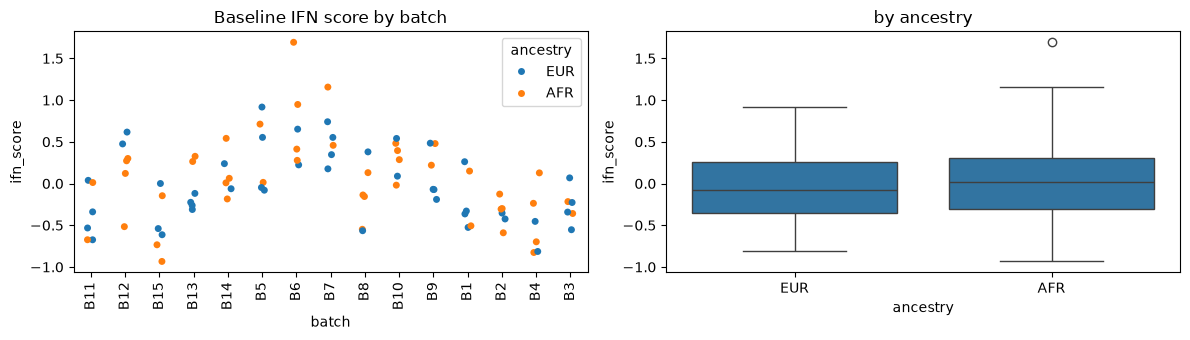

In [4]:
def logcpm(x): return np.log1p(x / max(x.sum(), 1) * 1e6)
IDX = META.groupby(["donor", "ct", "condition", "half"]).groups
def prof(d, ct, cond, h=None):
    rows = [i for hh in ([h] if h is not None else [0, 1]) for i in IDX.get((d, ct, cond, hh), [])]
    return SUMS[rows].sum(0), int(META.loc[rows, "n_cells"].sum()) if rows else 0

donors = sorted(DONOR_INFO.index)
gi_isg = [i for i, g in enumerate(genes) if g in set(ISG)]
per_ct = {}
for ct in CELL_TYPES:
    M = pd.DataFrame({d: logcpm(prof(d, ct, CONTROL)[0])[gi_isg] for d in donors if prof(d, ct, CONTROL)[1] >= 20}).T
    per_ct[ct] = ((M - M.mean(axis=0)) / (M.std(axis=0) + 1e-9)).mean(axis=1)
IFN = pd.DataFrame(per_ct).mean(axis=1).rename("ifn_score")
DONOR_INFO = DONOR_INFO.join(IFN)
DONOR_INFO.to_csv(f"{RESULTS_DIR}/randolph_donor_ifn.csv")
print(f"ISGs found: {len(gi_isg)}/{len(ISG)}")
print("IFN score by ancestry:\n", DONOR_INFO.groupby("ancestry").ifn_score.describe().round(2))
print("\nIFN score by batch:\n", DONOR_INFO.groupby("batch").ifn_score.agg(["count", "mean", "min", "max"]).round(2))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
sns.stripplot(data=DONOR_INFO.reset_index(), x="batch", y="ifn_score", hue="ancestry", ax=ax[0])
ax[0].set_title("Baseline IFN score by batch"); ax[0].tick_params(axis="x", rotation=90)
sns.boxplot(data=DONOR_INFO.reset_index(), x="ancestry", y="ifn_score", ax=ax[1]); ax[1].set_title("by ancestry")
plt.tight_layout(); fig.savefig(f"{RESULTS_DIR}/randolph_ifn_score.png", dpi=150); plt.show()

## 3. Corrected size/shape deviations

In [5]:
rng_thin = np.random.default_rng(SEED)
def thin(c, n_from, n_to):
    if n_from <= n_to: return c.astype(np.float64)
    return rng_thin.binomial(np.round(c).astype(np.int64), n_to / n_from).astype(np.float64)
def cross_parts(Ad, Bd, Ae, Be):
    nd, ne = np.sqrt(max(Ad @ Bd, 1e-12)), np.sqrt(max(Ae @ Be, 1e-12))
    cos = np.clip((Ad @ Be + Bd @ Ae) / 2 / (nd * ne), -1, 1)
    return (nd - ne) ** 2, 2 * nd * ne * (1 - cos)

PAIRS, USED = [], []
for ct in CELL_TYPES:
    raw = {}
    for d in donors:
        p = {k: prof(d, ct, c, h) for k, c, h in [("sA", STIM, 0), ("sB", STIM, 1), ("uA", CONTROL, 0), ("uB", CONTROL, 1)]}
        if min(n for _, n in p.values()) >= MIN_EQUAL_HALF: raw[d] = p
    if len(raw) < 10: print(ct, "skipped: too few donors"); continue
    t = min(n for p in raw.values() for _, n in p.values())
    R = {}
    for d, p in raw.items():
        th = {k: thin(s, n, t) for k, (s, n) in p.items()}
        R[d] = (logcpm(th["sA"]) - logcpm(th["uA"]), logcpm(th["sB"]) - logcpm(th["uB"]))
    expressed = np.expm1(np.mean([logcpm(prof(d, ct, CONTROL)[0]) for d in raw], 0)) >= MIN_CPM
    F = np.array([(a + b) / 2 for a, b in R.values()])
    gidx = np.argsort(np.where(expressed, F.var(0), -np.inf))[::-1][:min(N_GENES, expressed.sum())]
    A = {d: R[d][0][gidx] for d in R}; B = {d: R[d][1][gidx] for d in R}
    energy = np.mean([A[d] @ B[d] for d in R])
    USED.append(dict(ct=ct, donors=len(R), cells_per_half=t))
    for d, e in combinations(sorted(R), 2):
        m, s = cross_parts(A[d], B[d], A[e], B[e])
        PAIRS.append(dict(ct=ct, d=d, e=e, size=m / energy, shape=s / energy,
                          same_batch=DONOR_INFO.batch[d] == DONOR_INFO.batch[e],
                          same_ancestry=DONOR_INFO.ancestry[d] == DONOR_INFO.ancestry[e]))
PAIRS = pd.DataFrame(PAIRS)
PAIRS.to_csv(f"{RESULTS_DIR}/randolph_pairs.csv", index=False)
print(pd.DataFrame(USED).set_index("ct"))

           donors  cells_per_half
ct                               
CD4_T          90             172
CD8_T          87              20
B              79              20
NK             62              20
monocytes      78              21


## 4. Tests
- **all donors:** Spearman(IFN score, mean shape deviation against all other donors)
- **within batch:** deviation measured only against same-batch donors; IFN score centered within batch
- **within batch and ancestry:** same, with deviations against same-batch, same-ancestry donors and the score centered within batch x ancestry

Replication means `rho_shape` positive (and larger than `rho_size`) in the within-batch tests, at least in lymphocytes.

In [6]:
def donor_dev(g):
    long = pd.concat([g[["d", "size", "shape"]].rename(columns={"d": "donor"}),
                      g[["e", "size", "shape"]].rename(columns={"e": "donor"})])
    return long.groupby("donor")[["size", "shape"]].mean()

rows = []
for ct, g in PAIRS.groupby("ct"):
    for label, sub, grp in [("all donors", g, None),
                            ("within batch", g[g.same_batch], ["batch"]),
                            ("within batch and ancestry", g[g.same_batch & g.same_ancestry], ["batch", "ancestry"])]:
        dev = donor_dev(sub).join(DONOR_INFO)
        if grp:
            dev = dev[dev.groupby(grp).ifn_score.transform("count") >= 2]
            x = dev.ifn_score - dev.groupby(grp).ifn_score.transform("mean")
        else:
            x = dev.ifn_score
        if len(dev) < 10: continue
        r_sh, p_sh = spearmanr(x, dev["shape"]); r_si, p_si = spearmanr(x, dev["size"])
        rows.append(dict(ct=ct, test=label, n_donors=len(dev), rho_shape=r_sh, p_shape=p_sh, rho_size=r_si, p_size=p_si))
RAND_TEST = pd.DataFrame(rows).set_index(["ct", "test"]).round(3)
RAND_TEST.to_csv(f"{RESULTS_DIR}/randolph_tests.csv")
display(RAND_TEST)

# group view (as in Parse): top-quartile IFN score within batch vs others, same-batch pairs only
DONOR_INFO["ifn_within_batch"] = DONOR_INFO.ifn_score - DONOR_INFO.groupby("batch").ifn_score.transform("mean")
high = set(DONOR_INFO.index[DONOR_INFO.ifn_within_batch >= DONOR_INFO.ifn_within_batch.quantile(0.75)])
P = PAIRS[PAIRS.same_batch].copy()
P["pair"] = np.array(["non x non", "high x non", "high x high"])[P.d.isin(high).astype(int) + P.e.isin(high).astype(int)]
RAND_BY_PAIR = P.groupby(["ct", "pair"])[["size", "shape"]].mean().round(3)
RAND_BY_PAIR["share_size"] = (RAND_BY_PAIR["size"].clip(lower=0) /
                              (RAND_BY_PAIR["size"].clip(lower=0) + RAND_BY_PAIR["shape"].clip(lower=0))).round(2)
RAND_BY_PAIR.to_csv(f"{RESULTS_DIR}/randolph_by_pair.csv")
RAND_BY_PAIR

n_donors  rho_shape  p_shape  rho_size  \
ct        test                                                                
B         all donors                       79     -0.034    0.766    -0.091   
          within batch                     79     -0.051    0.656     0.070   
          within batch and ancestry        76      0.038    0.745    -0.006   
CD4_T     all donors                       90      0.132    0.214    -0.064   
          within batch                     90      0.049    0.645     0.003   
          within batch and ancestry        90      0.019    0.858    -0.041   
CD8_T     all donors                       87      0.058    0.593    -0.089   
          within batch                     87      0.030    0.783     0.058   
          within batch and ancestry        86      0.049    0.656     0.013   
NK        all donors                       62     -0.274    0.031     0.072   
          within batch                     62      0.001    0.995     0.025   
          within batch and ancestry        53      0.026    0.853    -0.026   
monocytes all donors                       78      0.155    0.175    -0.045   
          within batch                     78      0.059    0.607     0.045   
          within batch and ancestry        75      0.102    0.385    -0.016   

                                     p_size  
ct        test                               
B         all donors                  0.424  
          within batch                0.540  
          within batch and ancestry   0.960  
CD4_T     all donors                  0.552  
          within batch                0.980  
          within batch and ancestry   0.699  
CD8_T     all donors                  0.414  
          within batch                0.595  
          within batch and ancestry   0.904  
NK        all donors                  0.580  
          within batch                0.847  
          within batch and ancestry   0.852  
monocytes all donors                  0.697  
          within batch                0.697  
          within batch and ancestry   0.889

size  shape  share_size
ct        pair                                 
B         high x high  0.108  0.396        0.21
          high x non   0.058  0.659        0.08
          non x non    0.071  0.597        0.11
CD4_T     high x high  0.086  0.117        0.42
          high x non   0.078  0.139        0.36
          non x non    0.088  0.122        0.42
CD8_T     high x high  0.233  1.590        0.13
          high x non   0.141  1.503        0.09
          non x non    0.138  1.160        0.11
NK        high x high  0.245  0.904        0.21
          high x non   0.077  1.092        0.07
          non x non    0.065  1.183        0.05
monocytes high x high  0.050  0.139        0.26
          high x non   0.046  0.192        0.19
          non x non    0.038  0.162        0.19

In [7]:
# ===== 5. Response size and baseline interferon, after removing interferon-linked genes =====
# Same rule as in Parse and Aquino: remove the 20 ISGs plus the 0/25/40/55% of candidate genes whose
# baseline (NI) expression correlates most with the donor's interferon score; then relate response
# size (cross-half, relative to the other donors of the same batch) to the interferon score within batch.
# Run after sections 1-4 (needs SUMS, META, prof, donors, DONOR_INFO, genes, logcpm, thin, CELL_TYPES,
# STIM, CONTROL, MIN_EQUAL_HALF, MIN_CPM, N_GENES, gi_isg, RESULTS_DIR).
from scipy import stats
FRACS = [0.0, 0.25, 0.40, 0.55]
N_PERM_R = 5000

def rank_within(x, strata):
    s = pd.Series(np.asarray(x, float)).groupby(np.asarray(strata)).rank()
    return (s - s.groupby(np.asarray(strata)).transform("mean")).values

def within_spearman(x, y, strata, n_perm=N_PERM_R, seed=0):
    x, y, strata = np.asarray(x, float), np.asarray(y, float), np.asarray(strata)
    ok = np.isfinite(x) & np.isfinite(y); x, y, strata = x[ok], y[ok], strata[ok]
    ry = rank_within(y, strata)
    r = lambda xx: np.corrcoef(rank_within(xx, strata), ry)[0, 1]
    obs = r(x); rng = np.random.default_rng(seed); null = []
    for _ in range(n_perm):
        xp = x.copy()
        for s in np.unique(strata):
            i = np.where(strata == s)[0]; xp[i] = x[rng.permutation(i)]
        null.append(r(xp))
    return obs, (1 + np.sum(np.abs(null) >= abs(obs))) / (n_perm + 1), ok.sum()

rows = []
for ct in CELL_TYPES:
    rng_thin = np.random.default_rng(SEED)                     # same thinning as section 3
    raw = {}
    for d in donors:
        p = {k: prof(d, ct, c, h) for k, c, h in [("sA", STIM, 0), ("sB", STIM, 1), ("uA", CONTROL, 0), ("uB", CONTROL, 1)]}
        if min(n for _, n in p.values()) >= MIN_EQUAL_HALF: raw[d] = p
    if len(raw) < 10: continue
    t = min(n for p in raw.values() for _, n in p.values())
    R = {}
    for d, p in raw.items():
        th = {k: thin(s, n, t) for k, (s, n) in p.items()}
        R[d] = (logcpm(th["sA"]) - logcpm(th["uA"]), logcpm(th["sB"]) - logcpm(th["uB"]))
    dl = sorted(R)
    base = np.array([logcpm(prof(d, ct, CONTROL)[0]) for d in dl])         # baseline (NI) profiles
    expressed = np.expm1(base.mean(0)) >= MIN_CPM
    s = DONOR_INFO.loc[dl, "ifn_score"].values
    rho = np.zeros(base.shape[1])
    sr = stats.rankdata(s)
    for k in np.where(expressed)[0]:
        if base[:, k].std() > 0:
            rho[k] = np.corrcoef(stats.rankdata(base[:, k]), sr)[0, 1]
    F = np.array([(R[d][0] + R[d][1]) / 2 for d in dl])
    batch = DONOR_INFO.loc[dl, "batch"].values
    for frac in FRACS:
        keep = expressed.copy()
        if frac > 0:
            cut = np.quantile(np.abs(rho[expressed]), 1 - frac)
            keep &= np.abs(rho) < cut
            keep[gi_isg] = False
        gidx = np.argsort(np.where(keep, F.var(0), -np.inf))[::-1][:min(N_GENES, keep.sum())]
        A = np.array([R[d][0][gidx] for d in dl]); B = np.array([R[d][1][gidx] for d in dl])
        size = np.full(len(dl), np.nan)
        for j in range(len(dl)):
            oth = np.where((batch == batch[j]) & (np.arange(len(dl)) != j))[0]
            if len(oth) < 2: continue
            zz, mm = A[j] @ B[j], A[oth].mean(0) @ B[oth].mean(0)
            if zz > 0 and mm > 0: size[j] = np.sqrt(zz / mm)
        r_b, p_b, n = within_spearman(s, np.log(size), batch)
        anc = DONOR_INFO.loc[dl, "ancestry"].values
        r_ba, p_ba, _ = within_spearman(s, np.log(size), np.char.add(batch.astype(str), anc.astype(str)))
        rows.append(dict(ct=ct, frac_removed=frac, donors=n, cells_per_half=t,
                         rho_size_within_batch=r_b, p=p_b, rho_size_within_batch_ancestry=r_ba, p_ancestry=p_ba))
        print(rows[-1])
RAND_SIZE = pd.DataFrame(rows)
RAND_SIZE.to_csv(f"{RESULTS_DIR}/randolph_size_ifn_fractions.csv", index=False)
print(RAND_SIZE.pivot(index="ct", columns="frac_removed", values=["rho_size_within_batch", "p"]).round(3).to_string())

{'ct': 'CD4_T', 'frac_removed': 0.0, 'donors': np.int64(90), 'cells_per_half': 172, 'rho_size_within_batch': np.float64(-0.02095238095238095), 'p': np.float64(0.871625674865027), 'rho_size_within_batch_ancestry': np.float64(0.04938271604938272), 'p_ancestry': np.float64(0.753249350129974)}
{'ct': 'CD4_T', 'frac_removed': 0.25, 'donors': np.int64(90), 'cells_per_half': 172, 'rho_size_within_batch': np.float64(0.1619047619047619), 'p': np.float64(0.16816636672665466), 'rho_size_within_batch_ancestry': np.float64(0.1234567901234568), 'p_ancestry': np.float64(0.40511897620475906)}
{'ct': 'CD4_T', 'frac_removed': 0.4, 'donors': np.int64(87), 'cells_per_half': 172, 'rho_size_within_batch': np.float64(0.10833333333333331), 'p': np.float64(0.3749250149970006), 'rho_size_within_batch_ancestry': np.float64(0.11409395973154363), 'p_ancestry': np.float64(0.45870825834833034)}
{'ct': 'CD4_T', 'frac_removed': 0.55, 'donors': np.int64(89), 'cells_per_half': 172, 'rho_size_within_batch': np.float64(0.

saved results/aquino/Fig6C_size.png


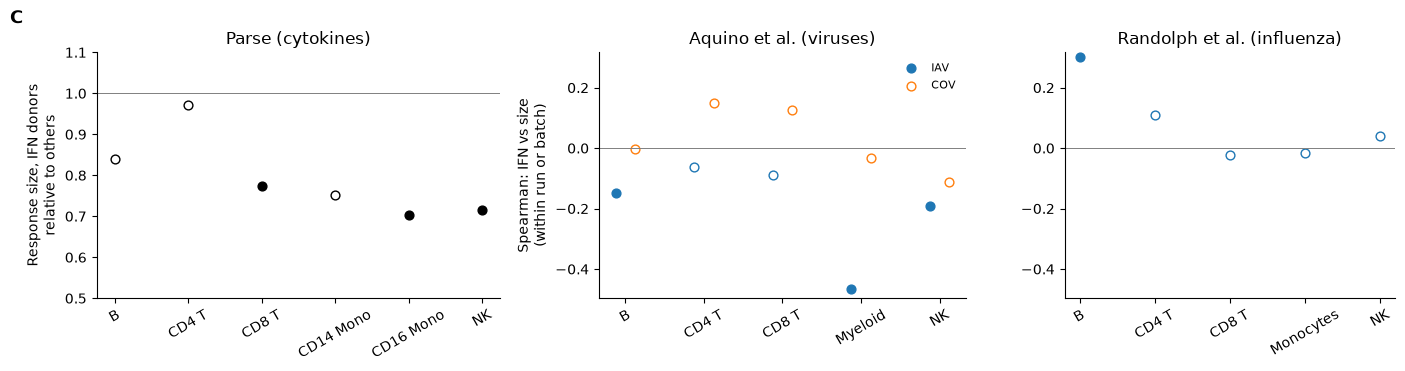

In [8]:
# Figure 6C with three datasets (Parse, Aquino et al., Randolph et al.), 40% of genes removed as
# interferon-linked. Standalone: run from the project folder in any notebook.
import glob, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def find(name):
    hits = [p for p in glob.glob(f"results/**/{name}", recursive=True) if ".ipynb_checkpoints" not in p]
    assert hits, f"{name} not found under results/"
    return max(hits, key=os.path.getmtime)

FRAC = 0.40
parse = pd.read_csv(find("ifn_size_parse_fractions.csv"))
aq = pd.read_csv(find("ifn_size_aquino_fractions.csv"))
rd = pd.read_csv(find("randolph_size_ifn_fractions.csv"))
mono_path = glob.glob("results/**/monocytes_only_check.csv", recursive=True)
COL = {"IAV": "#1f77b4", "COV": "#ff7f0e", "flu": "#1f77b4"}

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), gridspec_kw={"width_ratios": [1.1, 1, 0.9]})
# Parse
p = parse[np.isclose(parse.frac_removed, FRAC)].set_index("cell_type")
order = [c for c in ["B", "CD4 T", "CD8 T", "CD14 Mono", "CD16 Mono", "NK"] if c in p.index]
for i, c in enumerate(order):
    sig = p.loc[c, "p_smaller"] < 0.05
    ax[0].scatter(i, p.loc[c, "size_ratio"], s=40, color="black", facecolors="black" if sig else "white")
ax[0].axhline(1, color="grey", lw=0.7); ax[0].set_ylim(0.5, 1.1)
ax[0].set_xticks(range(len(order))); ax[0].set_xticklabels(order, rotation=30)
ax[0].set_ylabel("Response size, IFN donors\nrelative to others"); ax[0].set_title("Parse (cytokines)")
# Aquino
LAB = {"B": "B", "T.CD4": "CD4 T", "T.CD8": "CD8 T", "MONO": "Myeloid", "NK": "NK"}
lins = ["B", "T.CD4", "T.CD8", "MONO", "NK"]
for k, stim in enumerate(["IAV", "COV"]):
    g = aq[np.isclose(aq.frac_removed, FRAC) & (aq.stim == stim)].set_index("lineage").reindex(lins)
    for i, lin in enumerate(lins):
        sig = g.loc[lin, "p"] < 0.05
        ax[1].scatter(i + (k - 0.5) * 0.25, g.loc[lin, "rho_size"], s=40, color=COL[stim],
                      facecolors=COL[stim] if sig else "white", label=stim if i == 0 else None)
ax[1].set_xticks(range(len(lins))); ax[1].set_xticklabels([LAB[l] for l in lins], rotation=30)
ax[1].set_ylabel("Spearman: IFN vs size\n(within run or batch)"); ax[1].set_title("Aquino et al. (viruses)")
ax[1].legend(frameon=False, fontsize=8)
# Randolph
cts = ["B", "CD4_T", "CD8_T", "monocytes", "NK"]
g = rd[np.isclose(rd.frac_removed, FRAC)].set_index("ct").reindex(cts)
for i, c in enumerate(cts):
    sig = g.loc[c, "p"] < 0.05
    ax[2].scatter(i, g.loc[c, "rho_size_within_batch"], s=40, color=COL["flu"],
                  facecolors=COL["flu"] if sig else "white")
ax[2].set_xticks(range(len(cts))); ax[2].set_xticklabels(["B", "CD4 T", "CD8 T", "Monocytes", "NK"], rotation=30)
ax[2].set_title("Randolph et al. (influenza)")
lo = min(ax[1].get_ylim()[0], ax[2].get_ylim()[0]); hi = max(ax[1].get_ylim()[1], ax[2].get_ylim()[1])
for a in ax[1:]:
    a.set_ylim(lo, hi); a.axhline(0, color="grey", lw=0.7)
for a in ax: a.spines[["top", "right"]].set_visible(False)
fig.text(0.0, 0.98, "C", fontweight="bold", fontsize=13)
fig.tight_layout()
out = os.path.join(os.path.dirname(find("ifn_size_aquino_fractions.csv")), "Fig6C_size.png")
fig.savefig(out, dpi=300, bbox_inches="tight"); print("saved", out)

saved results/aquino/FigS6_response_size.png


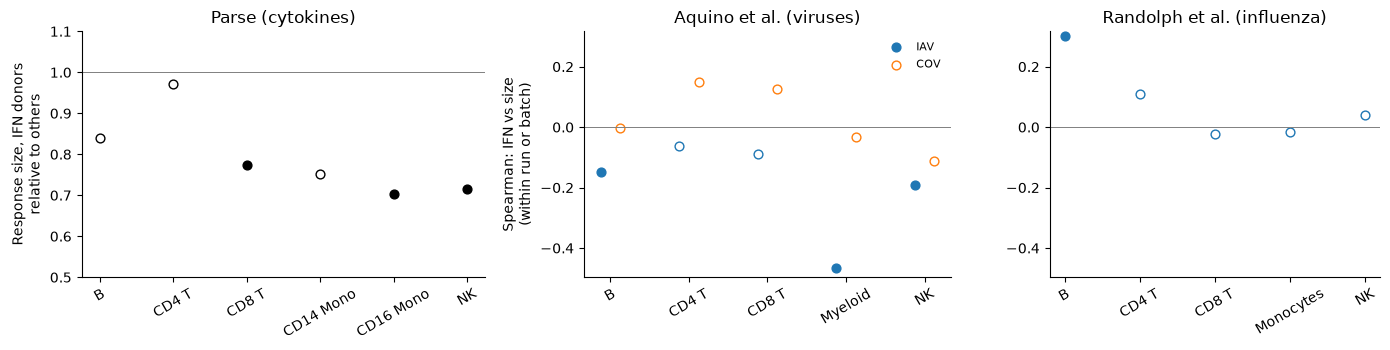

In [9]:
# Figure S6 with three datasets (Parse, Aquino et al., Randolph et al.), 40% of genes removed as
# interferon-linked. Standalone: run from the project folder in any notebook.
import glob, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def find(name):
    hits = [p for p in glob.glob(f"results/**/{name}", recursive=True) if ".ipynb_checkpoints" not in p]
    assert hits, f"{name} not found under results/"
    return max(hits, key=os.path.getmtime)

FRAC = 0.40
parse = pd.read_csv(find("ifn_size_parse_fractions.csv"))
aq = pd.read_csv(find("ifn_size_aquino_fractions.csv"))
rd = pd.read_csv(find("randolph_size_ifn_fractions.csv"))
mono_path = glob.glob("results/**/monocytes_only_check.csv", recursive=True)
COL = {"IAV": "#1f77b4", "COV": "#ff7f0e", "flu": "#1f77b4"}

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), gridspec_kw={"width_ratios": [1.1, 1, 0.9]})
# Parse
p = parse[np.isclose(parse.frac_removed, FRAC)].set_index("cell_type")
order = [c for c in ["B", "CD4 T", "CD8 T", "CD14 Mono", "CD16 Mono", "NK"] if c in p.index]
for i, c in enumerate(order):
    sig = p.loc[c, "p_smaller"] < 0.05
    ax[0].scatter(i, p.loc[c, "size_ratio"], s=40, color="black", facecolors="black" if sig else "white")
ax[0].axhline(1, color="grey", lw=0.7); ax[0].set_ylim(0.5, 1.1)
ax[0].set_xticks(range(len(order))); ax[0].set_xticklabels(order, rotation=30)
ax[0].set_ylabel("Response size, IFN donors\nrelative to others"); ax[0].set_title("Parse (cytokines)")
# Aquino
LAB = {"B": "B", "T.CD4": "CD4 T", "T.CD8": "CD8 T", "MONO": "Myeloid", "NK": "NK"}
lins = ["B", "T.CD4", "T.CD8", "MONO", "NK"]
for k, stim in enumerate(["IAV", "COV"]):
    g = aq[np.isclose(aq.frac_removed, FRAC) & (aq.stim == stim)].set_index("lineage").reindex(lins)
    for i, lin in enumerate(lins):
        sig = g.loc[lin, "p"] < 0.05
        ax[1].scatter(i + (k - 0.5) * 0.25, g.loc[lin, "rho_size"], s=40, color=COL[stim],
                      facecolors=COL[stim] if sig else "white", label=stim if i == 0 else None)
ax[1].set_xticks(range(len(lins))); ax[1].set_xticklabels([LAB[l] for l in lins], rotation=30)
ax[1].set_ylabel("Spearman: IFN vs size\n(within run or batch)"); ax[1].set_title("Aquino et al. (viruses)")
ax[1].legend(frameon=False, fontsize=8)
# Randolph
cts = ["B", "CD4_T", "CD8_T", "monocytes", "NK"]
g = rd[np.isclose(rd.frac_removed, FRAC)].set_index("ct").reindex(cts)
for i, c in enumerate(cts):
    sig = g.loc[c, "p"] < 0.05
    ax[2].scatter(i, g.loc[c, "rho_size_within_batch"], s=40, color=COL["flu"],
                  facecolors=COL["flu"] if sig else "white")
ax[2].set_xticks(range(len(cts))); ax[2].set_xticklabels(["B", "CD4 T", "CD8 T", "Monocytes", "NK"], rotation=30)
ax[2].set_title("Randolph et al. (influenza)")
lo = min(ax[1].get_ylim()[0], ax[2].get_ylim()[0]); hi = max(ax[1].get_ylim()[1], ax[2].get_ylim()[1])
for a in ax[1:]:
    a.set_ylim(lo, hi); a.axhline(0, color="grey", lw=0.7)
for a in ax: a.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
out = os.path.join(os.path.dirname(find("ifn_size_aquino_fractions.csv")), "FigS6_response_size.png")
fig.savefig(out, dpi=300, bbox_inches="tight"); print("saved", out)